In [11]:
# Tech Challenge FIAP — fase 2
## Projeto 1 — Otimização de Modelos de Diagnóstico para Saúde da Mulher

# **Aluno:** Nelson Seiji  
# **Objetivo do notebook:** otimização de hiperparâmetros com algoritmo genético

# otimizar hiperparâmetros do modelo Random Forest treinado no problema de classificação de tumores benignos e malignos
# encontrar uma combinação de hiperparâmetros que produza melhor desempenho no problema
# foco em sensibilidade (recall), falsos negativos, specificity e custo clínico aproximado

# o dataset utilizado neste estudo não apresenta variáveis demográficas populacionais.
# análise de equidade não pode ser implementada de forma completa e confiável

# Fluxo do Algoritmo Genético
# 1. gerar população inicial
# 2. avaliar aptidão dos indivíduos
# 3. verificar condição de término
# 4. selecionar indivíduos
# 5. aplicar cruzamento
# 6. aplicar mutação
# 7. formar nova população
# 8. repetir o processo


In [12]:
# Gene Space

# Este dicionário define o espaço de busca do algoritmo genético, cada chave é um hiperparâmetro da random forest
# os valores definem as possibilidades que o GA pode explorar

# Cada indivíduo da população representa uma combinação de hiperparâmetros da Random Forest
# hiperparâmetros são os "genes" do indivíduo.

# Em cada geração indivíduos são avaliados, melhores têm mais chance de gerar descendentes
# novos indivíduos surgem por cruzamento e mutação

# Genes serão n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features

gene_space = {
    "n_estimators": (5, 100),          # quantidade de árvores
    "max_depth": [None, 2,5,10],               # profundidade máxima de cada árvore
    "min_samples_split": (2, 10),       # mínimo para dividir um nó
    "min_samples_leaf": (1, 5),         # mínimo de amostras em uma folha
    "max_features": ["sqrt", "log2", None],  # número de features avaliadas em cada divisão
    "class_weight": [None, "balanced", "balanced_subsample"],    # ajusta peso da classe maligna podendo priorizar recall, None mantém pessos iguais
    "threshold": [0.30, 0.40, 0.50]       # limiar de probabilidades para classe, reduzir threshold classifica mais como positivo
}

gene_space

{'n_estimators': (5, 100),
 'max_depth': [None, 2, 5, 10],
 'min_samples_split': (2, 10),
 'min_samples_leaf': (1, 5),
 'max_features': ['sqrt', 'log2', None],
 'class_weight': [None, 'balanced', 'balanced_subsample'],
 'threshold': [0.3, 0.4, 0.5]}

In [13]:
# Parametros Gerais do Algoritmo Genético

# Experimento 1
tamanho_populacao_exp1 = 20
max_geracoes_exp1 = 5
taxa_mutacao_exp1 = 0.10
elite_size_exp1 = 1
tournament_size_exp1 = 1

# Experimento 2
tamanho_populacao_exp2 = 30
max_geracoes_exp2 = 10
taxa_mutacao_exp2 = 0.20
elite_size_exp2 = 2
tournament_size_exp2 = 2

# Experimento 3
tamanho_populacao_exp3 = 40
max_geracoes_exp3 = 15
taxa_mutacao_exp3 = 0.3
elite_size_exp3 = 2
tournament_size_exp3 = 3


In [14]:
# Configuração de reprodutibilidade

# random - sorteios aleatórios do algoritmo genético, seleção de indivíduos, crossover, mutação e população inicial
import random

RANDOM_STATE = 42

print("semente aleatória:", RANDOM_STATE)

semente aleatória: 42


In [15]:
# Carregamento do dataset para o Random Forest

# pandas - tabelas e manipulação de dados
import pandas as pd

# lê o arquivo csv da pasta data
df = pd.read_csv("../data/breast-cancer-wisconsin-data-set.csv")

# mostra o tamanho da base original
print("shape original do dataset:", df.shape)

# exibe as primeiras linhas para conferência
display(df.head())

shape original do dataset: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [16]:
# cópia da base original para evitar alteração acidental
df_clean = df.copy()

# remoção de colunas que não devem entrar no modelo
# id -> identificador sem valor preditivo
# unnamed: 32 -> coluna vazia/lixo estrutural
df_clean = df_clean.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# coluna auxiliar legível para interpretação e gráficos
df_clean["diagnosis_label"] = df_clean["diagnosis"].map({
    "B": "Benigno",
    "M": "Maligno"
})

# converter alvo para binário
# 0 = benigno
# 1 = maligno
df_clean["diagnosis"] = df_clean["diagnosis"].map({
    "B": 0,
    "M": 1
})

print("shape após cleaning", df_clean.shape)
display(df_clean.head())

shape após cleaning (569, 32)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_label
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Maligno
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Maligno
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Maligno
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Maligno
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Maligno


In [17]:
# Split mantendo a lógica do baseline - 60% treino 20% validação 20% teste
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["diagnosis", "diagnosis_label"])
y = df_clean["diagnosis"]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# Dos 80% restantes, separar 25% para Validação
# 25% de 80% é igual a 20% do total original, deixando 60% Treino e 20% Validação
# 80% entram em treino+validação e depois esse conjunto é dividido em 75/25, resultando em 60/20/20

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, 
    y_trainval, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_trainval
)

print(f"Dataset Original: {len(X)} amostras")
print("-" * 30)
print(f"Treino:     {X_train.shape[0]} amostras (60%)")
print(f"Validação:  {X_val.shape[0]} amostras (20%)")
print(f"Teste:      {X_test.shape[0]} amostras (20%)")

# Verificando se a proporção das classes se manteve (Garante que o Stratify funcionou)
print("\nProporção da classe alvo (Target) no Treino:")
print(y_train.value_counts(normalize=True))

print("\nProporção da classe alvo na validação:")
print(y_val.value_counts(normalize=True).round(4))

print("\nProporção da classe alvo no teste:")
print(y_test.value_counts(normalize=True).round(4))

Dataset Original: 569 amostras
------------------------------
Treino:     341 amostras (60%)
Validação:  114 amostras (20%)
Teste:      114 amostras (20%)

Proporção da classe alvo (Target) no Treino:
diagnosis
0    0.627566
1    0.372434
Name: proportion, dtype: float64

Proporção da classe alvo na validação:
diagnosis
0    0.6228
1    0.3772
Name: proportion, dtype: float64

Proporção da classe alvo no teste:
diagnosis
0    0.6316
1    0.3684
Name: proportion, dtype: float64


In [18]:
# como todas as colunas restantes são numéricas,
# o pipeline será simples:
# imputação por mediana + padronização

# pipeline - encadeia etapas de pré-processamento + modelo
from sklearn.pipeline import Pipeline

# columntransformer - aplica transformações em colunas específicas
from sklearn.compose import ColumnTransformer

# simpleimputer - trata valores ausentes
from sklearn.impute import SimpleImputer

# standardscaler - padroniza a escala das variáveis
from sklearn.preprocessing import StandardScaler

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_features)
    ],
    remainder="drop"
)

print("pré-processamento configurado")
print("quantidade de features:", len(numeric_features))

pré-processamento configurado
quantidade de features: 30


In [19]:
# Modelo Random Forest Baseline

# randomforestclassifier - modelo que será otimizado pelo algoritmo genético
from sklearn.ensemble import RandomForestClassifier

rf_baseline = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=10,
        max_depth=2,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_baseline.fit(X_train, y_train)

print("Random Forest Baseline treinado")

Random Forest Baseline treinado


In [20]:
# métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    fbeta_score
)

# avalia um conjunto de previsões e retorna métricas úteis para comparação.
# model_name - nome do modelo avaliado
# y_true - valores reais da variável alvo
# y_pred - previsões de classe
# y_proba - probabilidades previstas para a classe positiva

def evaluate_predictions(model_name, y_true, y_pred, y_proba):

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0), # F2 (beta=2) para priorizar Recall
        "specificity": specificity,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    # dict - dicionário com métricas de classificação e contagem da matriz de confusão
    return results

In [21]:
# previsões da baseline no conjunto de validação
y_val_proba_baseline = rf_baseline.predict_proba(X_val)[:, 1]
y_val_pred_baseline = (y_val_proba_baseline >= 0.50).astype(int)

baseline_val_results = evaluate_predictions(
    "RF Base (Validação)",
    y_val,
    y_val_pred_baseline,
    y_val_proba_baseline
)

baseline_val_df = pd.DataFrame([baseline_val_results])
display(baseline_val_df)

,model,accuracy,precision,recall,f1,f2,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,RF Base (Validação),0.921053,0.904762,0.883721,0.894118,0.88785,0.943662,0.973632,0.971138,67,4,5,38


In [22]:
# Define o “DNA” inicial do indivíduo gerando um indivíduo aleatório dentro do espaço de busca definido
# cada indivíduo é um dicionário de hiperparâmetros
# dicionário - permite que o código saiba exatamente o que cada número faz através de nomes

def gerar_individuo():
    
    # gene - cada par chave-valor dentro do dicionário (indivíduo)

    individuo = {
        "n_estimators": random.randint(gene_space["n_estimators"][0], gene_space["n_estimators"][1]),
        "max_depth": random.choice(gene_space["max_depth"]),
        "min_samples_split": random.randint(gene_space["min_samples_split"][0], gene_space["min_samples_split"][1]),
        "min_samples_leaf": random.randint(gene_space["min_samples_leaf"][0], gene_space["min_samples_leaf"][1]),
        "max_features": random.choice(gene_space["max_features"]),
        "class_weight": random.choice(gene_space["class_weight"]),
        "threshold": random.choice(gene_space["threshold"])
        
    }

    return individuo

In [23]:
# Gera a população inicial do algoritmo genético
# Cada indivíduo representa um conjunto de hiperparâmetros da Random Forest
# Tamanho da populacao parametrizado na função principal

def gerar_populacao_inicial(tamanho_populacao):        
    populacao = [gerar_individuo() for _ in range(tamanho_populacao)]
    return populacao

In [24]:
# Treina uma random forest com os hiperparâmetros do indivíduo e avalia no conjunto de validação

def evaluate_individuo(individuo, X_train, y_train, X_val, y_val):

    model = Pipeline(steps=[
        ("preprocess", preprocess_rf),
        ("model", RandomForestClassifier(
            n_estimators=individuo["n_estimators"],
            max_depth=individuo["max_depth"],
            min_samples_split=individuo["min_samples_split"],
            min_samples_leaf=individuo["min_samples_leaf"],
            max_features=individuo["max_features"],
            class_weight=individuo["class_weight"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_proba >= individuo["threshold"]).astype(int)

    metrics = evaluate_predictions(
        "candidate_rf",
        y_val,
        y_val_pred,
        y_val_proba
    )    

    return model, metrics

In [25]:
# métricas de validação em um score único de aptidão
# recall recebe maior peso por causa do risco clínico de falsos negativos
# specificity controla alarmes falsos
# f1 entra como medida de equilíbrio geral

# F-beta score (beta=2) dá mais importância ao Recall do que à Precisão
from sklearn.metrics import fbeta_score

def fitness_function(metrics):
    
    recall = metrics["recall"]
    specificity = metrics["specificity"]    
    f2 = metrics["f2"] 

    # 50% peso direto no recall, 20% para evitar alarmes falsos excessivos, 30% no F1 que reforça precisão    
    # f1 = metrics["f1"]    
    # fitness = ( 0.50 * recall + 0.25 * specificity + 0.25 * f1 )    

    # F2 gerencia equilíbrio entre Recall e Precisão de forma harmônica
    # specificity evita aumento excessivo de falsos positivos
    f2 = metrics["f2"]
    fitness = 0.8 * f2 + 0.2 * specificity

    return fitness

In [26]:
# Avalia cada indivíduo da população
# Para cada conjunto de hiperparâmetros (indivíduo), treina modelo, calcula métricas, calcula fitness
# A ordenação final permite identificar o melhor indivíduo da geração

def avaliar_populacao(populacao, X_train, y_train, X_val, y_val):
    
    populacao_avaliada = []

    for individuo in populacao:
        model, metrics = evaluate_individuo(individuo, X_train, y_train, X_val, y_val)
        fitness = fitness_function(metrics)

        populacao_avaliada.append({
            "individuo": individuo,
            "fitness": fitness,
            "metrics": metrics,
            "model": model
        })

    # ordena do melhor para o pior
    populacao_avaliada = sorted(populacao_avaliada, key=lambda x: x["fitness"], reverse=True)

    return populacao_avaliada

In [27]:
# Seleciona indivíduos para reprodução usando torneio
# para cada seleção, sorteia indivíduos da população avaliada
# entre os sorteados, escolhe o de maior fitness e repete até obter uma lista de pais para próxima geração
# mantém pressão seletiva, evita escolher sempre só os melhores globais, preserva mais diversidade na população

def selecao_por_torneio(populacao_avaliada, tamanho_torneio):

    selecionados = []

    for _ in range(len(populacao_avaliada)):

        # Sorteia competidores da população avaliada (que contém fitness/métricas)
        # escolhe n indivíduos ao acaso, evita que apenas o "melhor de todos" se reproduza mantendo a diversidade genética
        competidores = random.sample(populacao_avaliada, tamanho_torneio)
        
        # Dos n sorteados, coloca em ordem decrescente pelo fitness
        # sorted - gera lista organizada
        # competidores - lista original
        # key - usar critério específico
        # lambda x: - função anônima (rápida) representando um único item da lista
        # x[fitness] - usar valor da chave fitness para comparar
        # revese = True - crescente, True inverte para descrescente - maior primeiro
        competidores = sorted(competidores, key=lambda x: x["fitness"], reverse=True)

        # [0] - primeiro item da lista competidores, o com maior fitness
        vencedor = competidores[0]["individuo"]        

        # selecionados - anexa o vencedor na lista de pais com direito de reproduzir
        selecionados.append(vencedor)

    return selecionados

In [28]:
# Aplica mutação em um indivíduo do algoritmo genético
# mutação altera genes aleatoriamente para manter diversidade na população
# Sem mutação pode convergir cedo demais para soluções parecidas e deixar de explorar regiões melhores de solução
# mutation_rate é probabilidade de cada gene sofrer alteração
# mutação é aplicada gene a gene, e não no indivíduo inteiro de uma vez

def mutate(individuo, mutation_rate=0.15):
    
    mutated = individuo.copy()

    # random.random() gera um número entre 0 e 1
    # < mutation_rate - portão de portabilidade, garante que mutação seja rara

    if random.random() < mutation_rate:

        # sorteia um número inteiro entre o valor inicial e o final de cada parãmetro da lista gene_space        
        mutated["n_estimators"] = random.randint(gene_space["n_estimators"][0], gene_space["n_estimators"][1])

    if random.random() < mutation_rate:

        # escolhe um entre a lista de parâmetros max_depth - permite números e também "None"
        mutated["max_depth"] = random.choice(gene_space["max_depth"])

    if random.random() < mutation_rate:
        mutated["min_samples_split"] = random.randint(gene_space["min_samples_split"][0], gene_space["min_samples_split"][1])

    if random.random() < mutation_rate:
        mutated["min_samples_leaf"] = random.randint(gene_space["min_samples_leaf"][0], gene_space["min_samples_leaf"][1])

    if random.random() < mutation_rate:
        # escolhe um entre a lista de parâmetros max_features
        mutated["max_features"] = random.choice(gene_space["max_features"])

    return mutated

In [29]:
# Aplica mutação em todos os indivíduos da população

def aplicar_mutacao_populacao(populacao, taxa_mutacao=0.15):

    populacao_mutada = []

    for individuo in populacao:
        novo = mutate(individuo, mutation_rate=taxa_mutacao)
        populacao_mutada.append(novo)

    return populacao_mutada

In [30]:
# Aplica Elitismo
# Mantém melhores indivíduos e completa com novos indivíduos extraindo dicionário de hiperparâmetros dos melhores indivíduos
# Essa estratégia ajuda a evitar que uma boa solução seja perdida por acaso durante crossover ou mutação
# elite_size - quantos dos melhores indivíduos de uma geração são copiados diretamente para a próxima sem sofrer cruzamento ou mutação


def substituir_populacao(populacao_antiga, nova_populacao, elite_size):
    
    # pega apenas o valor da chave 'individuo'
    # populacao_antiga é lista de dicts que contém metadados
    # [:elite_size] pega os primeiros itens
    # item["individuo"] extrai os hiperparâmetros - DNA

    elite = [item["individuo"] for item in populacao_antiga[:elite_size]]

    # Completa a população com os novos filhos mutados
    # elite - sobreviventes da geração anterior
    # len(populacao_antiga) - elite_size - se tirou 2 vagas para elite, só pega filhos suficientes para preencher as vagas restantes
    nova = elite + nova_populacao[:len(populacao_antiga) - elite_size]

    return nova

In [31]:
# Gera dois filhos a partir de dois pais
# crossover por gene, para cada hiperparâmetro, escolhemos aleatoriamente se herdará do pai 1 ou do pai 2

def crossover(parent1, parent2):
    
    child1 = {}
    child2 = {}

    for gene in parent1.keys():

        # Sorteio random, 50% chance (<0.5)
        if random.random() < 0.5:

            # Se menor, filho 1 pega gene do pai 1 filho 2 pega gene do pai 2
            child1[gene] = parent1[gene]
            child2[gene] = parent2[gene]
        else:
            # Se maior, contrário
            child1[gene] = parent2[gene]
            child2[gene] = parent1[gene]

    return child1, child2

In [32]:
# Aplica crossover em uma populacao para gerar novos indivíduos

def cruzamento_populacao(populacao_selecionada):


    nova_populacao = []

    for i in range(0, len(populacao_selecionada), 2):
        pai1 = populacao_selecionada[i]
        pai2 = populacao_selecionada[(i + 1) % len(populacao_selecionada)]

        filho1, filho2 = crossover(pai1, pai2)

        nova_populacao.append(filho1)
        nova_populacao.append(filho2)

    return nova_populacao[:len(populacao_selecionada)]

In [33]:
import matplotlib.pyplot as plt 
from IPython.display import clear_output

def executar_algoritmo_genetico(
    X_train, y_train,
    X_val, y_val,
    tamanho_populacao=20,
    max_geracoes=20,
    taxa_mutacao=0.15,
    elite_size=2,          
    tournament_size=3      
):

    # 1. gerar população inicial
    populacao = gerar_populacao_inicial(tamanho_populacao)

    historico = []
    geracao = 0

    for geracao in range(max_geracoes):

        # 2. avaliar aptidão
        populacao_avaliada = avaliar_populacao(populacao, X_train, y_train, X_val, y_val)

        melhor = populacao_avaliada[0]

        # armazena métricas no histórico
        historico.append({
            "geracao": geracao + 1,
            "fitness": melhor["fitness"],
            "recall": melhor["metrics"]["recall"],
            "specificity": melhor["metrics"]["specificity"],
            "f2": melhor["metrics"]["f2"]            
        })
        
        # Atualização para feedback Gráfico e de texto a cada 10 gerações
        if (geracao + 1) % 1 == 0 or (geracao + 1) == max_geracoes:
            clear_output(wait=True)
            
            # Gráfico de evolução simples
            df_hist = pd.DataFrame(historico)
            df_hist.plot(x="geracao", y=["fitness", "recall"], figsize=(8, 4), grid=True)
            plt.title(f"Progresso até a Geração {geracao + 1}")
            plt.show()

            # Mostra a combinação do "DNA" dos melhores
            pai1 = populacao_avaliada[0]["individuo"]
            pai2 = populacao_avaliada[1]["individuo"]
            filho, _ = crossover(pai1, pai2) # Simulação rápida de cruzamento

            print(f"\n Geração {geracao + 1}")
            print(f"➔ Melhor Atual: {melhor['individuo']}")
            print(f"\n➔ Exemplo de Cruzamento com Elitismo:")
            print(f"   Pai A: {pai1}")
            print(f"   Pai B: {pai2}")
            print(f"   Filho: {filho} (Combinação gerada)")
            print("-" * 50) # linha separadora para clareza  

        # 4. seleção
        selecionados = selecao_por_torneio(populacao_avaliada, tamanho_torneio=tournament_size)

        # 5. cruzamento
        filhos = cruzamento_populacao(selecionados)

        # 6. mutação
        filhos_mutados = aplicar_mutacao_populacao(filhos, taxa_mutacao)

        # 7. substituição
        populacao = substituir_populacao(populacao_avaliada, filhos_mutados, elite_size)      

        print(f"geração {geracao+1} | fitness {melhor['fitness']:.4f}")
        print(f"   ➔ Parâmetros: {melhor['individuo']}")
        print("-" * 30) # Linha separadora para clareza  

    return melhor, pd.DataFrame(historico)

In [34]:
## experimento 1

# Primeiro experimento com configuração moderada:
# população = 20 | gerações = 20 | taxa de mutação = 0.10
# Esse experimento serve como ponto inicial

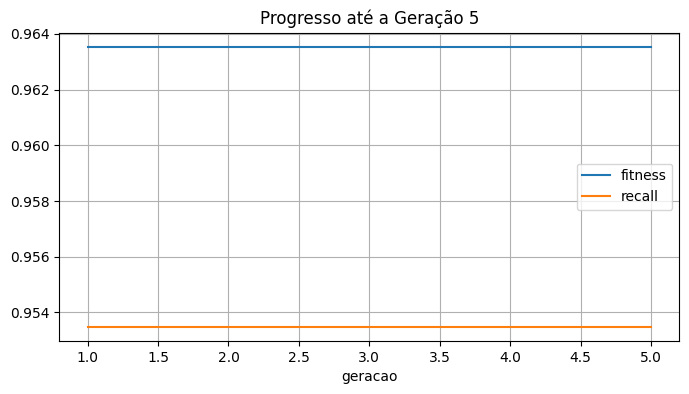


 Geração 5
➔ Melhor Atual: {'n_estimators': 60, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}

➔ Exemplo de Cruzamento com Elitismo:
   Pai A: {'n_estimators': 60, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}
   Pai B: {'n_estimators': 22, 'max_depth': None, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced', 'threshold': 0.5}
   Filho: {'n_estimators': 22, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5} (Combinação gerada)
--------------------------------------------------
geração 5 | fitness 0.9635
   ➔ Parâmetros: {'n_estimators': 60, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}
---------------------------

,geracao,fitness,recall,specificity,f2
0,1,0.963538,0.953488,0.985915,0.957944
1,2,0.963538,0.953488,0.985915,0.957944
2,3,0.963538,0.953488,0.985915,0.957944
3,4,0.963538,0.953488,0.985915,0.957944
4,5,0.963538,0.953488,0.985915,0.957944


,geracao,fitness,recall,specificity,f2
0,1,0.963538,0.953488,0.985915,0.957944
1,2,0.963538,0.953488,0.985915,0.957944
2,3,0.963538,0.953488,0.985915,0.957944
3,4,0.963538,0.953488,0.985915,0.957944
4,5,0.963538,0.953488,0.985915,0.957944


In [35]:
best_solution_exp1, history_exp1 = executar_algoritmo_genetico(
    X_train,
    y_train,
    X_val,
    y_val,
    tamanho_populacao=tamanho_populacao_exp1,
    max_geracoes=max_geracoes_exp1,
    taxa_mutacao=taxa_mutacao_exp1,
    elite_size=elite_size_exp1,
    tournament_size=tournament_size_exp1
)

display(history_exp1.head())
display(history_exp1.tail())

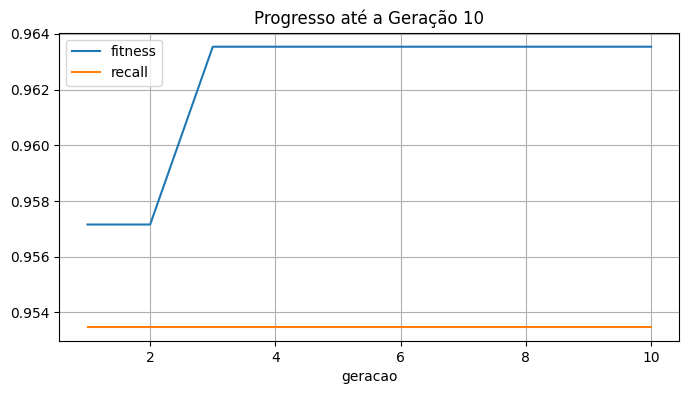


 Geração 10
➔ Melhor Atual: {'n_estimators': 89, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced', 'threshold': 0.5}

➔ Exemplo de Cruzamento com Elitismo:
   Pai A: {'n_estimators': 89, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced', 'threshold': 0.5}
   Pai B: {'n_estimators': 89, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced_subsample', 'threshold': 0.5}
   Filho: {'n_estimators': 89, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced', 'threshold': 0.5} (Combinação gerada)
--------------------------------------------------
geração 10 | fitness 0.9635
   ➔ Parâmetros: {'n_estimators': 89, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced', 'threshold': 0.5}
-

In [36]:
best_solution_exp2, history_exp2 = executar_algoritmo_genetico(
    X_train,
    y_train,
    X_val,
    y_val,
    tamanho_populacao=tamanho_populacao_exp2,
    max_geracoes=max_geracoes_exp2,
    taxa_mutacao=taxa_mutacao_exp2,
    elite_size=elite_size_exp2,
    tournament_size=tournament_size_exp2
)

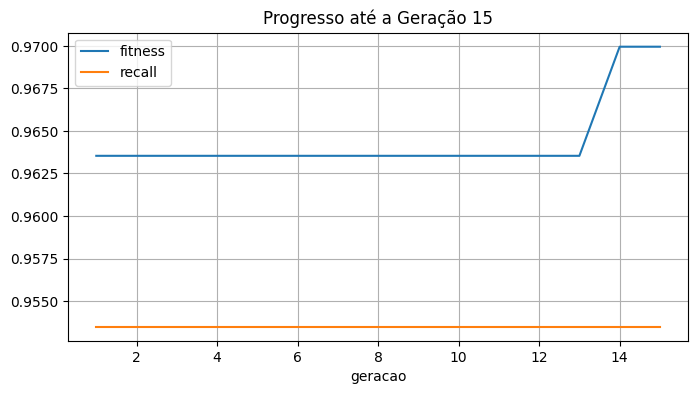


 Geração 15
➔ Melhor Atual: {'n_estimators': 61, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}

➔ Exemplo de Cruzamento com Elitismo:
   Pai A: {'n_estimators': 61, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}
   Pai B: {'n_estimators': 61, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': None, 'threshold': 0.5}
   Filho: {'n_estimators': 61, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None, 'threshold': 0.5} (Combinação gerada)
--------------------------------------------------
geração 15 | fitness 0.9700
   ➔ Parâmetros: {'n_estimators': 61, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}
------------------------------


In [37]:
best_solution_exp3, history_exp3 = executar_algoritmo_genetico(
    X_train,
    y_train,
    X_val,
    y_val,
    tamanho_populacao=tamanho_populacao_exp3,
    max_geracoes=max_geracoes_exp3,
    taxa_mutacao=taxa_mutacao_exp3,
    elite_size=elite_size_exp3,
    tournament_size=tournament_size_exp3
)

In [38]:
experiment_summary = pd.DataFrame([
    {
        "experiment": "exp1",
        "population_size": 20,
        "generations": 20,
        "mutation_rate": 0.10,
        "best_fitness": best_solution_exp1["fitness"],
        "recall": best_solution_exp1["metrics"]["recall"],
        "specificity": best_solution_exp1["metrics"]["specificity"],
        "f1": best_solution_exp1["metrics"]["f1"],        
        "params": best_solution_exp1["individuo"]
    },
    {
        "experiment": "exp2",
        "population_size": 30,
        "generations": 25,
        "mutation_rate": 0.15,
        "best_fitness": best_solution_exp2["fitness"],
        "recall": best_solution_exp2["metrics"]["recall"],
        "specificity": best_solution_exp2["metrics"]["specificity"],
        "f1": best_solution_exp2["metrics"]["f1"],
        "params": best_solution_exp2["individuo"]
    },
    {
        "experiment": "exp3",
        "population_size": 40,
        "generations": 30,
        "mutation_rate": 0.20,
        "best_fitness": best_solution_exp3["fitness"],
        "recall": best_solution_exp3["metrics"]["recall"],
        "specificity": best_solution_exp3["metrics"]["specificity"],
        "f1": best_solution_exp3["metrics"]["f1"],
        "params": best_solution_exp3["individuo"]
    }
])

display(experiment_summary.sort_values(by="best_fitness", ascending=False))

,experiment,population_size,generations,mutation_rate,best_fitness,recall,specificity,f1,params
2,exp3,40,30,0.20,0.969953,0.953488,1.000000,0.976190,"{'n_estimators': 61, 'max_depth': 5, 'min_samp..."
0,exp1,20,20,0.10,0.963538,0.953488,0.985915,0.964706,"{'n_estimators': 60, 'max_depth': None, 'min_s..."
1,exp2,30,25,0.15,0.963538,0.953488,0.985915,0.964706,"{'n_estimators': 89, 'max_depth': 10, 'min_sam..."


In [39]:
# escolhemos o melhor experimento com base no fitness
# se houver empate próximo, vale comentar o trade-off no texto

best_experiment_name = experiment_summary.sort_values(by="best_fitness", ascending=False).iloc[0]["experiment"]
print("melhor experimento:", best_experiment_name)

if best_experiment_name == "exp1":
    best_solution = best_solution_exp1
    best_history = history_exp1
elif best_experiment_name == "exp2":
    best_solution = best_solution_exp2
    best_history = history_exp2
else:
    best_solution = best_solution_exp3
    best_history = history_exp3

print("melhores hiperparâmetros encontrados:")
print(best_solution["individuo"])

melhor experimento: exp3
melhores hiperparâmetros encontrados:
{'n_estimators': 61, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}


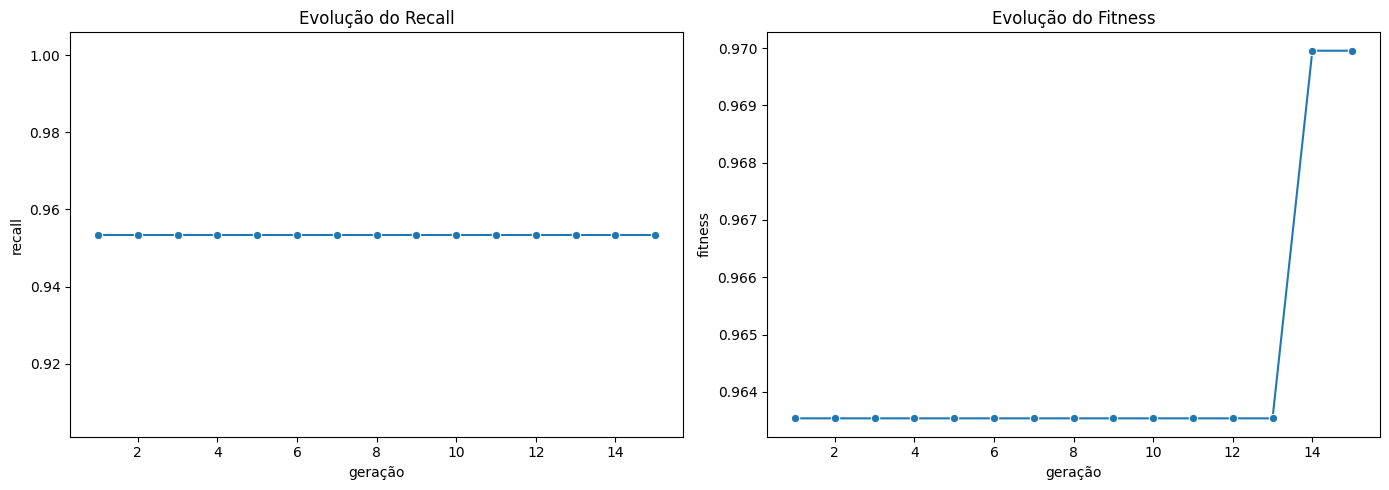

In [40]:
# Biblioteca base para criar gráficos
import matplotlib.pyplot as plt 

# Biblioteca construída sobre o matplotlib para gráficos estatísticos mais bonitos
import seaborn as sns           

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=best_history, x="geracao", y="recall", marker="o", ax=axes[0])
axes[0].set_title("Evolução do Recall")
axes[0].set_xlabel("geração")
axes[0].set_ylabel("recall")

sns.lineplot(data=best_history, x="geracao", y="fitness", marker="o", ax=axes[1])
axes[1].set_title("Evolução do Fitness")
axes[1].set_xlabel("geração")
axes[1].set_ylabel("fitness")

plt.tight_layout()
plt.show()

In [41]:
best_params = best_solution["individuo"]

rf_optimized = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        class_weight=best_params["class_weight"],
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# treina novamente no treino
rf_optimized.fit(X_train, y_train)

print("modelo otimizado treinado com sucesso")
print("parâmetros usados:", best_params)

modelo otimizado treinado com sucesso
parâmetros usados: {'n_estimators': 61, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None, 'threshold': 0.5}


In [42]:
# baseline no teste
y_test_proba_baseline = rf_baseline.predict_proba(X_test)[:, 1]
y_test_pred_baseline = (y_test_proba_baseline >= 0.50).astype(int)

baseline_test_results = evaluate_predictions(
    "Random Forest baseline",
    y_test,
    y_test_pred_baseline,
    y_test_proba_baseline
)

# otimizado no teste
y_test_proba_optimized = rf_optimized.predict_proba(X_test)[:, 1]
y_test_pred_optimized = (y_test_proba_optimized >= best_params["threshold"]).astype(int)

optimized_test_results = evaluate_predictions(
    "Random Forest otimizada por GA",
    y_test,
    y_test_pred_optimized,
    y_test_proba_optimized
)

comparison_df = pd.DataFrame([
    baseline_test_results,
    optimized_test_results
])

display(comparison_df)

,model,accuracy,precision,recall,f1,f2,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Random Forest baseline,0.947368,1.0,0.857143,0.923077,0.882353,1.0,0.996693,0.994637,72,0,6,36
1,Random Forest otimizada por GA,0.973684,1.0,0.928571,0.962963,0.942029,1.0,0.997024,0.995336,72,0,3,39


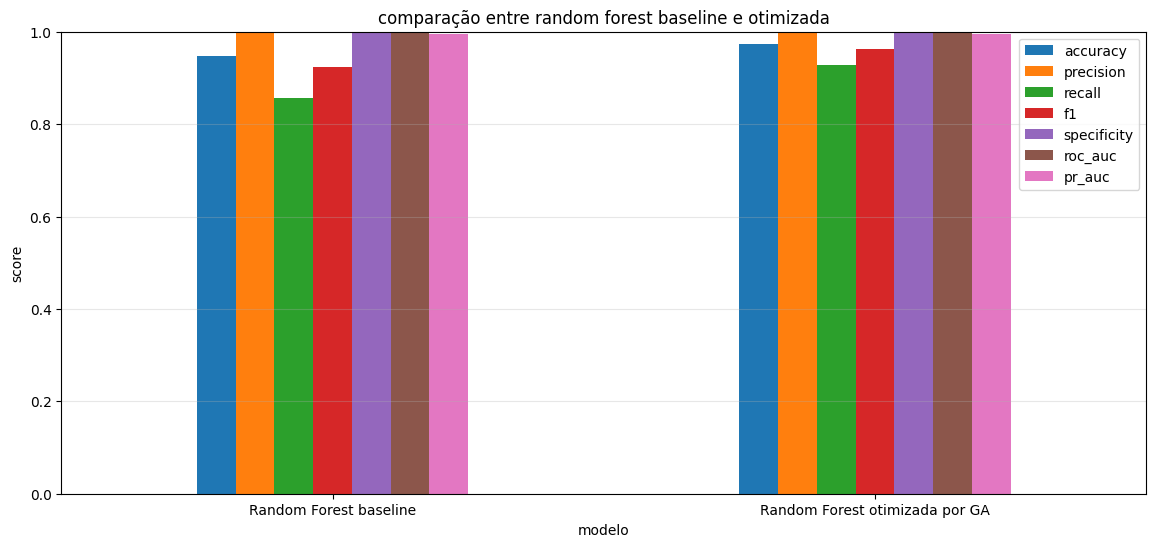

In [43]:

import matplotlib.pyplot as plt 

metrics_to_plot = ["accuracy", "precision", "recall", "f1", "specificity", "roc_auc", "pr_auc"]

plot_df = comparison_df.set_index("model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("comparação entre random forest baseline e otimizada")
plt.ylabel("score")
plt.xlabel("modelo")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

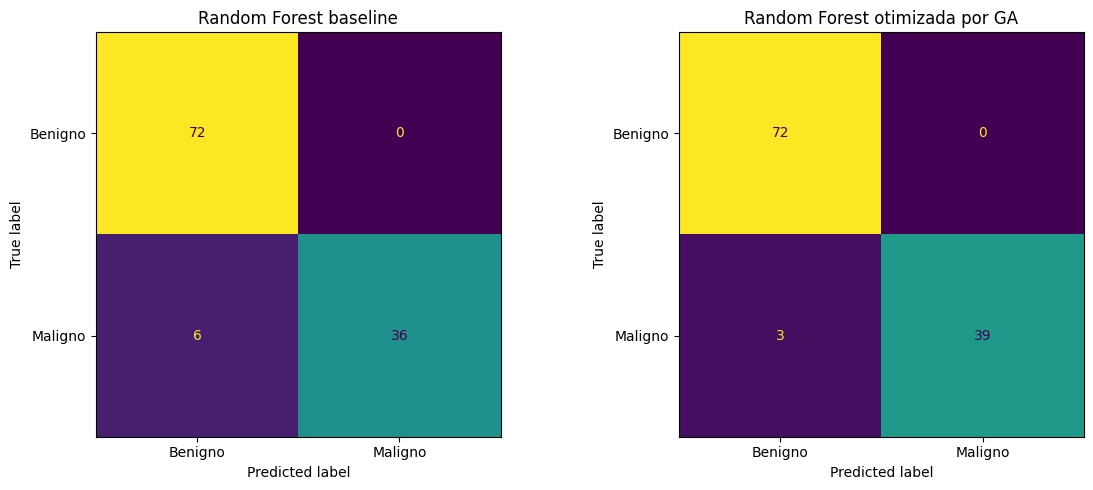

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_baseline = confusion_matrix(y_test, y_test_pred_baseline)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=["Benigno", "Maligno"])
disp1.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Random Forest baseline")

cm_optimized = confusion_matrix(y_test, y_test_pred_optimized)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_optimized, display_labels=["Benigno", "Maligno"])
disp2.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest otimizada por GA")

plt.tight_layout()
plt.show()

In [45]:
## Interpretação dos resultados

# A comparação final entre a Random Forest baseline e a versão otimizada por algoritmo genético deve ser analisada com cuidado


In [46]:
import json

# salva a comparação final em csv para uso em relatório
comparison_df.to_csv("../outputs/ga_rf_comparison.csv", index=False)

# salva o melhor histórico evolutivo
best_history.to_csv("../outputs/ga_rf_history.csv", index=False)

# salva os melhores hiperparâmetros em json
with open("../outputs/ga_best_params.json", "w", encoding="utf-8") as f:
    json.dump(best_params, f, ensure_ascii=False, indent=4)

print("resultados salvos com sucesso")

resultados salvos com sucesso


In [47]:
"""
Conclusão desta etapa

O modelo baseline apresentou desempenho elevado, com alta especificidade e precisão, porém com limitações na detecção de todos os casos malignos, resultando em mais falsos negativos

A aplicação do algoritmo genético permitiu explorar automaticamente diferentes combinações de hiperparâmetros da Random Forest

O modelo otimizado apresentou Aumento do recall, redução de falsos negativos e leve aumento de falsos positivos

Esse comportamento representa um trade-off esperado e aceitável no contexto de diagnóstico médico, no qual é preferível investigar casos adicionais do que deixar de identificar uma condição potencialmente grave

O algoritmo genético convergiu rapidamente para soluções de alta qualidade, indicando que o problema possui uma região ótima relativamente acessível no espaço de busca. Isso é coerente com o fato de que uma Random Forest simples já apresenta forte desempenho nesse dataset

Destaca-se o tamanho reduzido do dataset, que restringe o espaço de melhoria e pode levar a resultados altamente estáveis

Além disso, a convergência rápida do GA sugere que métodos mais simples de otimização poderiam atingir resultados semelhantes neste cenário específico

Apesar disso, o uso do algoritmo genético foi relevante para demonstrar uma abordagem automatizada de otimização, permitindo avaliar diferentes configurações de forma sistemática e alinhada ao objetivo clínico

"""

'\nConclusão desta etapa\n\nO modelo baseline apresentou desempenho elevado, com alta especificidade e precisão, porém com limitações na detecção de todos os casos malignos, resultando em mais falsos negativos\n\nA aplicação do algoritmo genético permitiu explorar automaticamente diferentes combinações de hiperparâmetros da Random Forest\n\nO modelo otimizado apresentou Aumento do recall, redução de falsos negativos e leve aumento de falsos positivos\n\nEsse comportamento representa um trade-off esperado e aceitável no contexto de diagnóstico médico, no qual é preferível investigar casos adicionais do que deixar de identificar uma condição potencialmente grave\n\nO algoritmo genético convergiu rapidamente para soluções de alta qualidade, indicando que o problema possui uma região ótima relativamente acessível no espaço de busca. Isso é coerente com o fato de que uma Random Forest simples já apresenta forte desempenho nesse dataset\n\nDestaca-se o tamanho reduzido do dataset, que restri

In [57]:
# Importar funções .py para LLM
import sys
from pathlib import Path
import importlib

# Localiza a raiz do projeto e a pasta src
project_root = Path.cwd().parent
src_path = project_root / "src"

# Adiciona a pasta src na lista de busca do Python
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

import llm_openai
importlib.reload(llm_openai)

from llm_openai import (
    generate_llm_interpretation,
    save_llm_response,
    append_llm_jsonl_record
)

In [64]:
# Selecionar caso para interpretação por LLM

# Escolher primeiro caso predito como maligno

import numpy as np
import pandas as pd

# Encontrar indice do modelo otimizado predito como Classe 1 (maligno)
malignant_pred_indices = np.where(y_test_pred_optimized == 1)[0]

if len(malignant_pred_indices) == 0:
    raise ValueError("Valor maligno não foi encontrado")

selected_idx = malignant_pred_indices[0]

print("Indice selecionado:", selected_idx)
print("True Label:", y_test.iloc[selected_idx])
print("Predicted Label:", y_test_pred_optimized[selected_idx])
print("Probabilidade predição:", y_test_proba_optimized[selected_idx])

# Recupera valores das features do caso de teste selecionado

selected_case_features = X_test.iloc[selected_idx][[
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean",
    "concave points_mean"
]].to_dict()

selected_case_features

Indice selecionado: 1
True Label: 1
Predicted Label: 1
Probabilidade predição: 0.9981789013860436


{'radius_mean': 20.94,
 'texture_mean': 23.56,
 'perimeter_mean': 138.9,
 'area_mean': 1364.0,
 'concavity_mean': 0.2712,
 'concave points_mean': 0.131}

In [65]:
# Payload para LLM

selected_probability = float(y_test_proba_optimized[selected_idx])
selected_predicted_class = "maligno" if y_test_pred_optimized[selected_idx] == 1 else "benigno"

llm_input_payload = {

    # Dados de predição
    "predicted_class": selected_predicted_class,
    "predicted_probability": selected_probability,
    "model_metrics": {
        "recall": float(optimized_test_results["recall"]),
        "specificity": float(optimized_test_results["specificity"]),
        "precision": float(optimized_test_results["precision"]),
        "fn": int(optimized_test_results["fn"]),
        "fp": int(optimized_test_results["fp"])
    },

    # Dados das features do caso
    "case_features": selected_case_features,

    # Contexto
    "context_note": (
        "Este resultado vem de um modelo de apoio à triagem de tumores em um contexto educacional/acadêmico. O foco do projeto é reduzir "
        "falsos negativos, pois deixar um caso maligno passar despercebido é clinicamente mais crítico do que investigar um falso positivo."
    )
}

llm_input_payload



{'predicted_class': 'maligno',
 'predicted_probability': 0.9981789013860436,
 'model_metrics': {'recall': 0.9285714285714286,
  'specificity': 1.0,
  'precision': 1.0,
  'fn': 3,
  'fp': 0},
 'case_features': {'radius_mean': 20.94,
  'texture_mean': 23.56,
  'perimeter_mean': 138.9,
  'area_mean': 1364.0,
  'concavity_mean': 0.2712,
  'concave points_mean': 0.131},
 'context_note': 'Este resultado vem de um modelo de apoio à triagem de tumores em um contexto educacional/acadêmico. O foco do projeto é reduzir falsos negativos, pois deixar um caso maligno passar despercebido é clinicamente mais crítico do que investigar um falso positivo.'}

In [66]:
# Gera interpretação com API OpenAI
from llm_openai import generate_llm_interpretation

llm_result = generate_llm_interpretation(
    predicted_class=llm_input_payload["predicted_class"],
    predicted_probability=llm_input_payload["predicted_probability"],
    recall=llm_input_payload["model_metrics"]["recall"],
    specificity=llm_input_payload["model_metrics"]["specificity"],
    precision=llm_input_payload["model_metrics"]["precision"],
    fn=llm_input_payload["model_metrics"]["fn"],
    fp=llm_input_payload["model_metrics"]["fp"],
    case_features=selected_case_features,
    context_note=llm_input_payload["context_note"]
)

print(llm_result["response_text"])

1. Interpretação do resultado  
O modelo previu uma alta probabilidade de malignidade (0,9982) para o caso apresentado, com base nas características morfológicas indicadas, incluindo valores elevados de radius_mean, perimeter_mean, area_mean, concavity_mean e concave points_mean. Essas características, conforme evidenciado pelo treinamento do modelo, estão associadas a um perfil de maior suspeita para malignidade no contexto desta ferramenta de triagem.

2. Nível de cautela clínica  
É fundamental enfatizar que este resultado representa apenas uma predição automatizada e não constitui diagnóstico definitivo. A interpretação deve ser sempre integrada ao exame clínico, histórico da paciente e exames complementares realizados por profissionais capacitados, de forma a garantir uma avaliação segura e adequada.

3. Limitações do modelo  
O modelo utilizado apresenta bom desempenho geral, com alta especificidade e precisão, refletindo baixa propensão a falsos positivos. No entanto, há ocorrên

In [ ]:
# Salvar resposta
from llm_openai import save_llm_response, append_llm_jsonl_record

saved_json_path = save_llm_response(llm_result)
print("Resposta JSON OpenAI salva:", saved_json_path)

saved_jsonl_path = append_llm_jsonl_record(
    input_payload=llm_input_payload,
    prompt=llm_result["prompt"],
    output_text=llm_result["response_text"],
    model_name=llm_result["model_name"]
)
print("Resposta JSONL anexada em:", saved_jsonl_path)



Resposta JSON OpenAI salva: ..\outputs\llm_response_20260322_041408.json


TypeError: append_llm_jsonl_record() got an unexpected keyword argument 'prompt'